# Table of Contents

1. Introduction
2. Dataset Information
3. Exploratory Data Analysis
4. Data Preparation
5. Handling Class Imbalance
6. Data Augmentation
7. Custom CNN
8. MobileNetV2
9. EfficientNetB0
10. VGG16
11. Model Evaluation
12. Grad-CAM Visualization
13. Model Comparison
14. Conclusion
15. Future Scope

# Pneumonia Chest X-ray Classification using Deep Learning and Transfer Learning

## Project Goal

Build a deep learning model that can classify chest X-ray images into:

- Normal
- Pneumonia

We will train and compare four models:

1. Custom CNN
2. MobileNetV2
3. EfficientNetB0
4. VGG16

Finally, we will compare all models and select the best one.

# Dataset Information

The dataset contains chest X-ray images divided into three folders:

- train
- val
- test

Each folder contains two classes:

- NORMAL
- PNEUMONIA

Image size will be converted to 224 × 224 for all models.

In [3]:
# Import library to access files and folders

import os

# Import library for numerical operations

import numpy as np

# Import library for plotting graphs

import matplotlib.pyplot as plt

# Import library for data visualization

import seaborn as sns

# Import OpenCV library for image processing

import cv2

# Ignore warning messages

import warnings

warnings.filterwarnings('ignore')

In [4]:
# Import TensorFlow

import tensorflow as tf

# Import ImageDataGenerator for loading images

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Import Sequential model

from tensorflow.keras.models import Sequential

# Import layers used in CNN

from tensorflow.keras.layers import (

    Input,

    Conv2D,

    MaxPooling2D,

    Flatten,

    Dense,

    Dropout,

    GlobalAveragePooling2D

)

# Import callbacks

from tensorflow.keras.callbacks import (

    EarlyStopping,

    ModelCheckpoint

)

# Mount Google Drive

The dataset zip file is stored in Google Drive.

We will mount Google Drive so that Colab can access the dataset.

In [5]:
# Mount Google Drive

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# Extract Dataset

The dataset is available as a zip file.

We will extract the zip file so that we can access the images.

In [6]:
# Show files present in Google Drive root folder

os.listdir("/content/drive/MyDrive")

['Untitled document.gdoc',
 'Voice 018.m4a',
 'Voice 017.m4a',
 'Colab Notebooks',
 'Traffic_data.zip',
 'Traffic_Sign_Project',
 'Pneumonia_Chest_Xray_Project']

In [7]:
# Show files inside Pneumonia_Chest_Xray_Project folder

os.listdir("/content/drive/MyDrive/Pneumonia_Chest_Xray_Project")

['Chest-Xray-2.zip',
 'Pneumonia_Chest_Xray_Classification.ipynb',
 'Pneumonia_Chest_Xray_Classification_claude.ipynb',
 'Untitled0.ipynb']

In [9]:
import zipfile
# Path of zip file

zip_path = "/content/drive/MyDrive/Pneumonia_Chest_Xray_Project/Chest-Xray-2.zip"

# Extract dataset

with zipfile.ZipFile(zip_path, 'r') as zip_ref:

    zip_ref.extractall("/content/chest_xray_data")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [10]:
# Show extracted folders

os.listdir("/content/chest_xray_data")

['chest_xray']

In [11]:
# Show dataset folder

os.listdir("/content/chest_xray_data/chest_xray")

['val', 'test', 'train']

# Define Dataset Paths

We will create paths for:

- Training data
- Validation data
- Testing data

In [12]:
# Path of training folder

train_path = "/content/chest_xray_data/chest_xray/train"

# Path of validation folder

val_path = "/content/chest_xray_data/chest_xray/val"

# Path of test folder

test_path = "/content/chest_xray_data/chest_xray/test"

# Exploratory Data Analysis (EDA)

Before training the models, we need to understand the dataset.

In this section, we will:

- Count images in each folder.
- Check class distribution.
- Visualize sample images.
- Understand whether the dataset is balanced or not.

This will help us understand the data better before training the models.

In [13]:
# Show extracted folders

print(os.listdir("/content/chest_xray_data"))

# Show dataset folder

print(os.listdir("/content/chest_xray_data/chest_xray"))

['chest_xray']
['val', 'test', 'train']


In [14]:
# Define dataset paths

train_path = "/content/chest_xray_data/chest_xray/train"

val_path = "/content/chest_xray_data/chest_xray/val"

test_path = "/content/chest_xray_data/chest_xray/test"

# Count Images in Each Class

Now we will count the number of images present in:

- Training folder
- Validation folder
- Test folder

This will help us understand the class distribution.

In [15]:
# Count training images

train_normal = len(os.listdir(os.path.join(train_path, "NORMAL")))

train_pneumonia = len(os.listdir(os.path.join(train_path, "PNEUMONIA")))


# Count validation images

val_normal = len(os.listdir(os.path.join(val_path, "NORMAL")))

val_pneumonia = len(os.listdir(os.path.join(val_path, "PNEUMONIA")))


# Count test images

test_normal = len(os.listdir(os.path.join(test_path, "NORMAL")))

test_pneumonia = len(os.listdir(os.path.join(test_path, "PNEUMONIA")))

In [16]:
# Print image counts

print("Training Images")

print("Normal Images    :", train_normal)

print("Pneumonia Images :", train_pneumonia)

print()


print("Validation Images")

print("Normal Images    :", val_normal)

print("Pneumonia Images :", val_pneumonia)

print()


print("Testing Images")

print("Normal Images    :", test_normal)

print("Pneumonia Images :", test_pneumonia)

Training Images
Normal Images    : 1342
Pneumonia Images : 3876

Validation Images
Normal Images    : 9
Pneumonia Images : 9

Testing Images
Normal Images    : 234
Pneumonia Images : 390


# Observation

The number of images in the two classes may not be equal.

If one class contains more images than the other, the dataset is called imbalanced.

We will study this in more detail in the next section and handle it properly before training the models.

# Create DataFrame for Class Distribution

Now we will create a small DataFrame.

This will help us visualize the number of images present in each class.

Later, we will use this DataFrame to create graphs.

In [17]:
# Import pandas

import pandas as pd


# Create dictionary containing class names and image counts

data = {

    "Class": ["Normal", "Pneumonia"],

    "Count": [train_normal, train_pneumonia]

}


# Convert dictionary into DataFrame

df = pd.DataFrame(data)


# Display DataFrame

df

,Class,Count
0,Normal,1342
1,Pneumonia,3876


# Visualize Class Distribution

Now we will create a count plot.

This graph will help us understand whether the dataset is balanced or imbalanced.

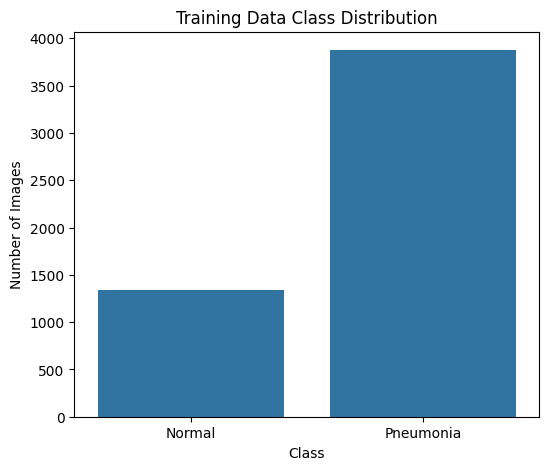

In [18]:
# Create figure

plt.figure(figsize=(6,5))


# Create bar plot

sns.barplot(

    x="Class",

    y="Count",

    data=df

)


# Add title

plt.title("Training Data Class Distribution")


# Add labels

plt.xlabel("Class")

plt.ylabel("Number of Images")


# Show graph

plt.show()

# Observation

The number of Pneumonia images is greater than the number of Normal images.

This means the dataset is imbalanced.

Because of this, the model may learn one class better than the other.

We will solve this problem later using class weights.

# Pie Chart

Now we will create a pie chart.

This will help us understand the percentage of each class.

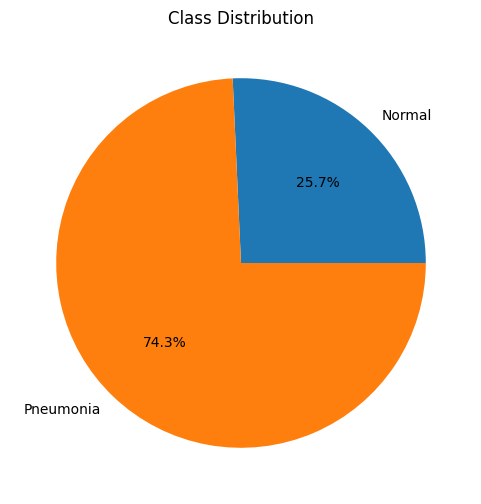

In [19]:
# Create figure

plt.figure(figsize=(6,6))


# Create pie chart

plt.pie(

    df["Count"],

    labels=df["Class"],

    autopct="%1.1f%%"

)


# Add title

plt.title("Class Distribution")


# Show plot

plt.show()

# Observation

The pie chart also shows that the dataset contains more Pneumonia images.

Therefore, the dataset is imbalanced.

We will handle this imbalance before training the models.

# Display Sample Images

Now we will display some sample images from both classes.

This will help us understand how Normal and Pneumonia chest X-ray images look.

Visualizing the images is an important part of EDA.

In [20]:
# Get path of Normal images

normal_path = os.path.join(train_path, "NORMAL")


# Get path of Pneumonia images

pneumonia_path = os.path.join(train_path, "PNEUMONIA")


# Show first few image names

print(os.listdir(normal_path)[:5])

print(os.listdir(pneumonia_path)[:5])

['IM-0565-0001.jpeg', 'IM-0317-0001.jpeg', 'NORMAL2-IM-0530-0001.jpeg', 'IM-0564-0001.jpeg', 'NORMAL2-IM-0552-0001.jpeg']
['person979_virus_1654.jpeg', 'person1771_bacteria_4615.jpeg', 'person1634_bacteria_4334.jpeg', 'person310_bacteria_1450.jpeg', 'person931_virus_1592.jpeg']


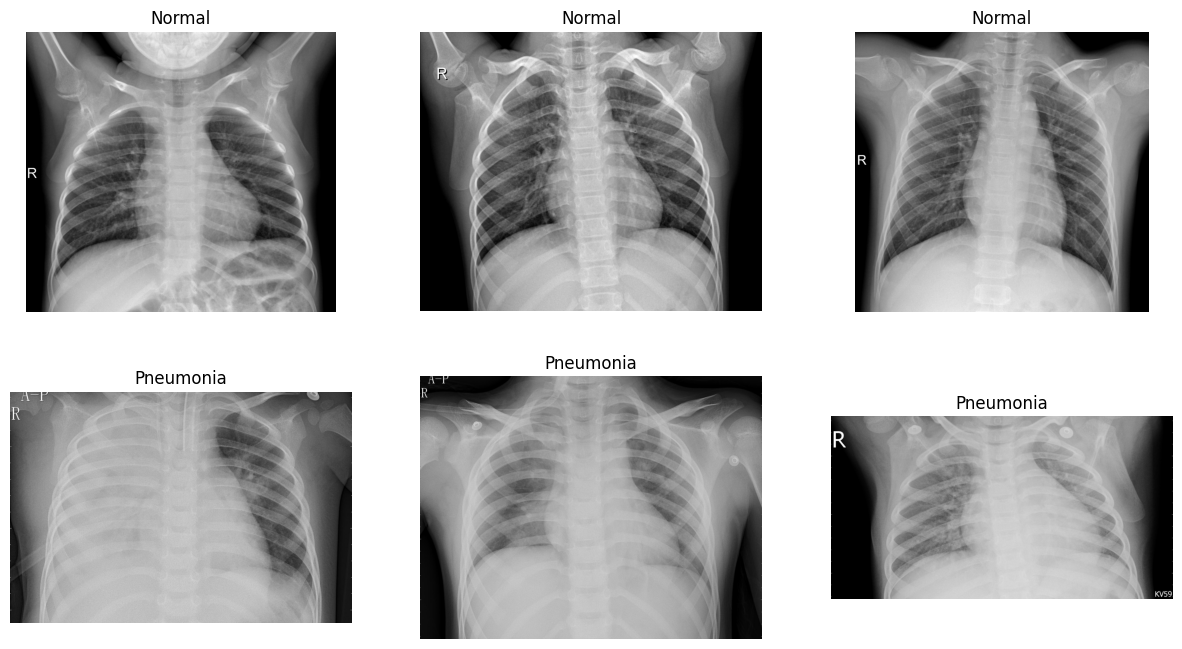

In [21]:
# Create figure

plt.figure(figsize=(15,8))


# Display 3 Normal images

for i, image_name in enumerate(os.listdir(normal_path)[:3]):

    # Read image

    image = cv2.imread(os.path.join(normal_path, image_name))

    # Convert BGR to RGB

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Create subplot

    plt.subplot(2,3,i+1)

    # Show image

    plt.imshow(image)

    # Add title

    plt.title("Normal")

    # Remove axis

    plt.axis("off")


# Display 3 Pneumonia images

for i, image_name in enumerate(os.listdir(pneumonia_path)[:3]):

    # Read image

    image = cv2.imread(os.path.join(pneumonia_path, image_name))

    # Convert BGR to RGB

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Create subplot

    plt.subplot(2,3,i+4)

    # Show image

    plt.imshow(image)

    # Add title

    plt.title("Pneumonia")

    # Remove axis

    plt.axis("off")


# Show all images

plt.show()

# Observation

Normal and Pneumonia chest X-ray images look very similar.

It is difficult for humans to distinguish between them.

Therefore, we will use deep learning models to learn patterns from the images and classify them automatically.

# Observation

Normal and Pneumonia chest X-ray images look very similar.

It is difficult for humans to distinguish between them.

Therefore, we will use deep learning models to learn patterns from the images and classify them automatically.

In [22]:
# Read one Normal image

sample_normal = cv2.imread(

    os.path.join(

        normal_path,

        os.listdir(normal_path)[0]

    )

)


# Read one Pneumonia image

sample_pneumonia = cv2.imread(

    os.path.join(

        pneumonia_path,

        os.listdir(pneumonia_path)[0]

    )

)

In [23]:
# Print image shapes

print("Normal Image Shape    :", sample_normal.shape)

print("Pneumonia Image Shape :", sample_pneumonia.shape)

Normal Image Shape    : (1755, 1940, 3)
Pneumonia Image Shape : (888, 1312, 3)


# Observation

Image sizes may not be the same.

Deep learning models require a fixed image size.

Therefore, we will resize all images to:

224 × 224

This size works well with:

- Custom CNN
- MobileNetV2
- EfficientNetB0
- VGG16

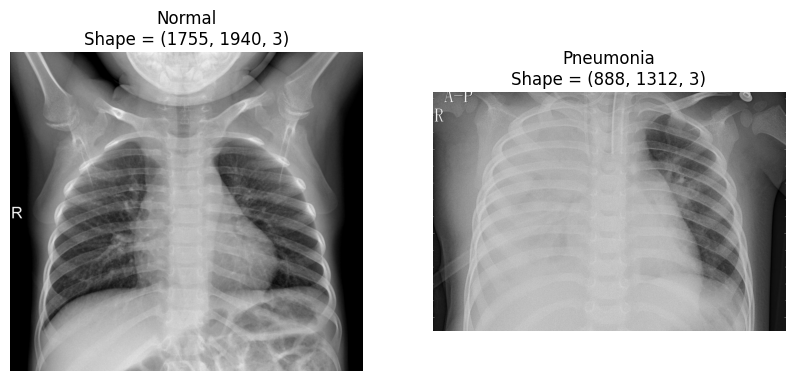

In [24]:
# Create figure

plt.figure(figsize=(10,5))


# Show Normal image

plt.subplot(1,2,1)

plt.imshow(

    cv2.cvtColor(

        sample_normal,

        cv2.COLOR_BGR2RGB

    )

)

plt.title(

    f"Normal\nShape = {sample_normal.shape}"

)

plt.axis("off")


# Show Pneumonia image

plt.subplot(1,2,2)

plt.imshow(

    cv2.cvtColor(

        sample_pneumonia,

        cv2.COLOR_BGR2RGB

    )

)

plt.title(

    f"Pneumonia\nShape = {sample_pneumonia.shape}"

)

plt.axis("off")


# Show images

plt.show()

# EDA Summary

In this section we:

- Explored the dataset.
- Counted images in each class.
- Visualized class distribution.
- Displayed sample images.
- Checked image dimensions.

We found that:

- Pneumonia images are more than Normal images.
- The dataset is imbalanced.
- Images may have different sizes.
- All images will be resized to 224 × 224.

Now we are ready to study class imbalance and prepare the data for model training.

# EDA Summary

In this section we:

- Explored the dataset.
- Counted images in each class.
- Visualized class distribution.
- Displayed sample images.
- Checked image dimensions.

We found that:

- Pneumonia images are more than Normal images.
- The dataset is imbalanced.
- Images may have different sizes.
- All images will be resized to 224 × 224.

Now we are ready to study class imbalance and prepare the data for model training.

# Why are we using Class Weights?

There are different ways to handle class imbalance.

Some common methods are:

- Oversampling
- Undersampling
- Class Weights

In this project, we will use class weights.

We are not using oversampling because it creates duplicate images.

We are not using undersampling because it removes useful images.

Class weights are simple and work well with deep learning models.

Therefore, class weights are a better choice for this project.

# Data Preparation

Now we will prepare the data for training.

We will use ImageDataGenerator.

This method loads images in small batches instead of loading everything into memory.

This helps:

- Save RAM
- Prevent session crashes
- Train large datasets efficiently

This is the recommended approach for image classification projects.

In [25]:
# Create data generator for training images

train_datagen = ImageDataGenerator(

    # Rescale pixel values between 0 and 1

    rescale=1./255,

    # Randomly rotate images

    rotation_range=20,

    # Randomly zoom images

    zoom_range=0.2,

    # Randomly shift images horizontally

    width_shift_range=0.1,

    # Randomly shift images vertically

    height_shift_range=0.1,

    # Randomly flip images

    horizontal_flip=True

)

In [26]:
# Create generator for validation images

val_datagen = ImageDataGenerator(

    # Normalize pixel values

    rescale=1./255

)


# Create generator for test images

test_datagen = ImageDataGenerator(

    # Normalize pixel values

    rescale=1./255

)

# What is Data Augmentation?

Data augmentation creates slightly different versions of the same image.

Examples:

- Rotation
- Zoom
- Shift
- Flip

This helps the model see more variations.

It also helps reduce overfitting and improve generalization.

In [27]:
# Create training generator

train_generator = train_datagen.flow_from_directory(

    # Training folder

    train_path,

    # Resize images to 224 x 224

    target_size=(224,224),

    # Number of images per batch

    batch_size=32,

    # Use categorical labels

    class_mode='categorical'

)

Found 5216 images belonging to 2 classes.


In [28]:
# Create validation generator

val_generator = val_datagen.flow_from_directory(

    val_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical'

)

Found 16 images belonging to 2 classes.


In [29]:
# Create test generator

test_generator = test_datagen.flow_from_directory(

    test_path,

    target_size=(224,224),

    batch_size=32,

    # Disable shuffling for evaluation

    shuffle=False,

    class_mode='categorical'

)

Found 624 images belonging to 2 classes.


In [30]:
# Print class labels

print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


# Visualize Data Augmentation

Data augmentation creates slightly different versions of the same image.

This helps the model see more variations.

Examples:

- Rotation
- Zoom
- Shift
- Flip

This helps improve model performance and reduce overfitting.

In [31]:
# Get one batch of training images

images, labels = next(train_generator)

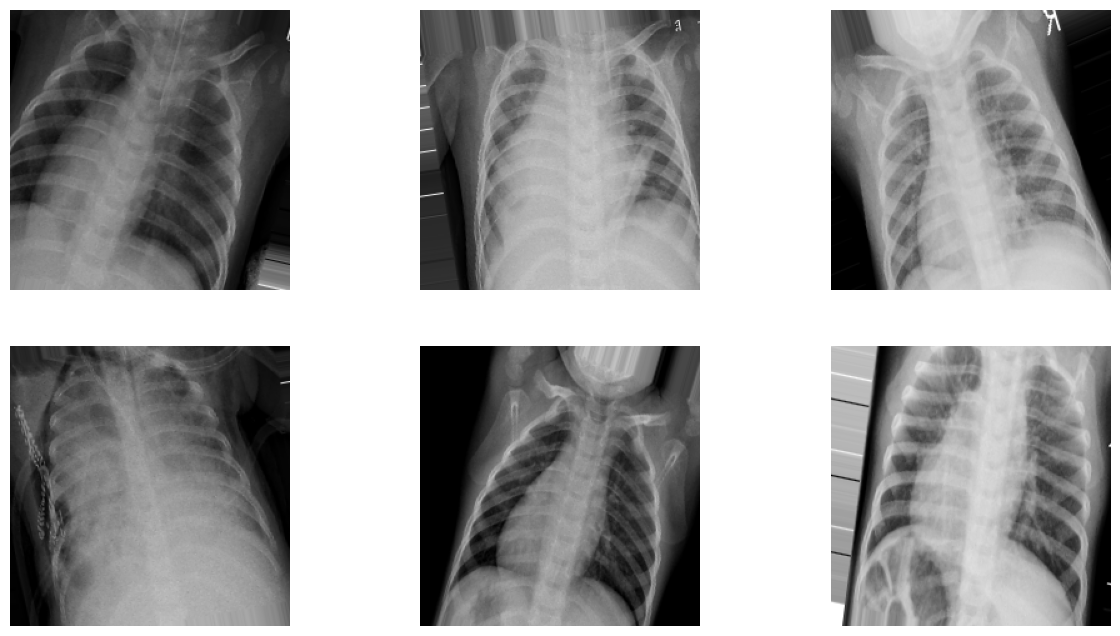

In [32]:
# Create figure

plt.figure(figsize=(15,8))


# Display six augmented images

for i in range(6):

    # Create subplot

    plt.subplot(2,3,i+1)

    # Show image

    plt.imshow(images[i])

    # Remove axis

    plt.axis("off")


# Display images

plt.show()

# Observation

The images are slightly different from each other.

Some images are rotated.

Some images are shifted.

Some images are zoomed.

These changes help the model learn better and reduce overfitting.

# Compute Class Weights

The dataset contains more Pneumonia images than Normal images.

To help the model learn both classes properly, we will use class weights.

Class weights give extra importance to the smaller class.

In [33]:
# Import class_weight

from sklearn.utils.class_weight import compute_class_weight

In [34]:
# Compute class weights

class_weights = compute_class_weight(

    class_weight='balanced',

    classes=np.unique(train_generator.classes),

    y=train_generator.classes

)

In [35]:
# Convert class weights into dictionary

class_weights = dict(

    enumerate(class_weights)

)


# Print class weights

print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


# Observation

The Normal class has fewer images.

Therefore, it receives a larger class weight.

This helps the model pay more attention to the smaller class.

As a result, both classes are learned more fairly.

# Data Preparation Summary

In this section we:

- Created data generators.
- Applied data augmentation.
- Visualized augmented images.
- Created training, validation and test generators.
- Computed class weights.

Now the dataset is ready for model training.

Next, we will build our first model:

# Custom CNN

# Custom CNN Model

Now we will build our first deep learning model.

CNN stands for Convolutional Neural Network.

CNN is specially designed for image classification problems.

The main purpose of CNN is to automatically learn important features from images.

Our CNN architecture contains:

1. Input Layer
2. Convolution Layers
3. Pooling Layers
4. Flatten Layer
5. Dense Layer
6. Dropout Layer
7. Output Layer

This model will act as our baseline model.

Later, we will compare it with transfer learning models.

# Understanding the Architecture

Conv2D Layer
-------------
Learns important patterns from images.

MaxPooling Layer
----------------
Reduces image size and keeps important information.

Flatten Layer
--------------
Converts feature maps into a single vector.

Dense Layer
------------
Learns relationships between features.

Dropout Layer
--------------
Helps reduce overfitting.

Output Layer
-------------
Predicts whether the image belongs to:

- Normal
- Pneumonia

In [36]:
# Build Custom CNN model

cnn_model = Sequential([

    # Input layer

    Input(shape=(224,224,3)),


    # First convolution layer

    Conv2D(

        filters=32,

        kernel_size=(3,3),

        activation='relu'

    ),

    # First pooling layer

    MaxPooling2D(pool_size=(2,2)),


    # Second convolution layer

    Conv2D(

        filters=64,

        kernel_size=(3,3),

        activation='relu'

    ),

    # Second pooling layer

    MaxPooling2D(pool_size=(2,2)),


    # Third convolution layer

    Conv2D(

        filters=128,

        kernel_size=(3,3),

        activation='relu'

    ),

    # Third pooling layer

    MaxPooling2D(pool_size=(2,2)),


    # Convert feature maps into one vector

    Flatten(),


    # Fully connected layer

    Dense(

        units=128,

        activation='relu'

    ),


    # Dropout layer to reduce overfitting

    Dropout(0.5),


    # Output layer

    Dense(

        units=2,

        activation='softmax'

    )

])

# Model Summary

Now we will check the architecture of our CNN model.

This helps us understand:

- Number of layers
- Output shape
- Number of trainable parameters

In [37]:
# Display model summary

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# Compile the Model

Before training, we need to compile the model.

Optimizer
---------
Adam optimizer helps update weights during training.

Loss Function
-------------
Categorical crossentropy is used because we have two classes.

Evaluation Metric
----------------
Accuracy will tell us how well the model is performing.

In [38]:
# Compile CNN model

cnn_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

# Callbacks

EarlyStopping
--------------
Stops training when validation accuracy stops improving.

ModelCheckpoint
----------------
Automatically saves the best model.

These callbacks help prevent overfitting and save training time.

In [39]:
# Create EarlyStopping callback

early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=3,

    restore_best_weights=True

)


# Create ModelCheckpoint callback

checkpoint = ModelCheckpoint(

    filepath='best_cnn_model.keras',

    monitor='val_accuracy',

    save_best_only=True

)

# Train Custom CNN Model

Now we will train our CNN model.

During training:

- The model will learn patterns from images.
- Validation data will help us monitor performance.
- Class weights will help handle class imbalance.
- EarlyStopping will prevent unnecessary training.
- ModelCheckpoint will save the best model.

We will train the model for 15 epochs.

In [40]:
# Train CNN model

history_cnn = cnn_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=15,

    class_weight=class_weights,

    callbacks=[

        early_stop,

        checkpoint

    ]

)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 696ms/step - accuracy: 0.7191 - loss: 0.5587 - val_accuracy: 0.8125 - val_loss: 0.5175
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 662ms/step - accuracy: 0.8307 - loss: 0.3595 - val_accuracy: 0.8125 - val_loss: 0.4881
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 656ms/step - accuracy: 0.8533 - loss: 0.3327 - val_accuracy: 0.8125 - val_loss: 0.4145
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 645ms/step - accuracy: 0.8723 - loss: 0.3017 - val_accuracy: 0.8750 - val_loss: 0.3594
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 662ms/step - accuracy: 0.8815 - loss: 0.2819 - val_accuracy: 0.8125 - val_loss: 0.5473
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 638ms/step - accuracy: 0.8852 - loss: 0.2669 - val_accuracy: 0.7500 - val_loss: 0.3901
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 664ms/step - accuracy: 0.8953 - loss: 0.2428 - val_accuracy: 0.8125 - val_loss: 0.3795


# Plot Accuracy Curve

Accuracy tells us how well the model is performing.

We will compare:

- Training Accuracy
- Validation Accuracy

This helps us understand whether the model is learning properly.

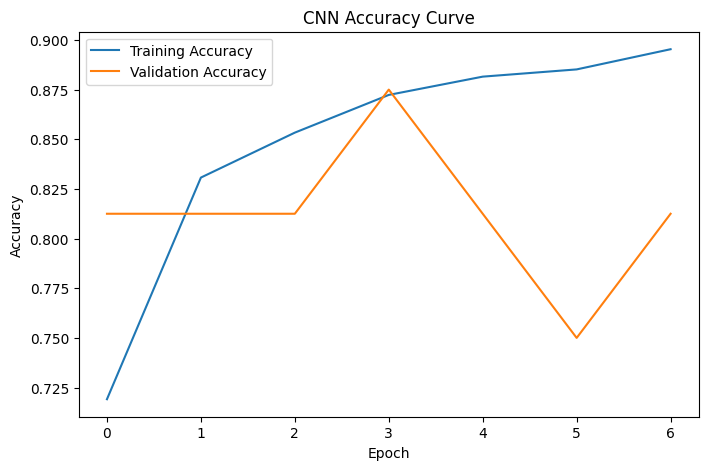

In [41]:
# Create figure

plt.figure(figsize=(8,5))


# Plot training accuracy

plt.plot(

    history_cnn.history['accuracy'],

    label='Training Accuracy'

)


# Plot validation accuracy

plt.plot(

    history_cnn.history['val_accuracy'],

    label='Validation Accuracy'

)


# Add title

plt.title("CNN Accuracy Curve")


# Add axis labels

plt.xlabel("Epoch")

plt.ylabel("Accuracy")


# Show legend

plt.legend()


# Show graph

plt.show()

# Plot Loss Curve

Loss tells us how much error the model is making.

Lower loss means better learning.

We will compare:

- Training Loss
- Validation Loss

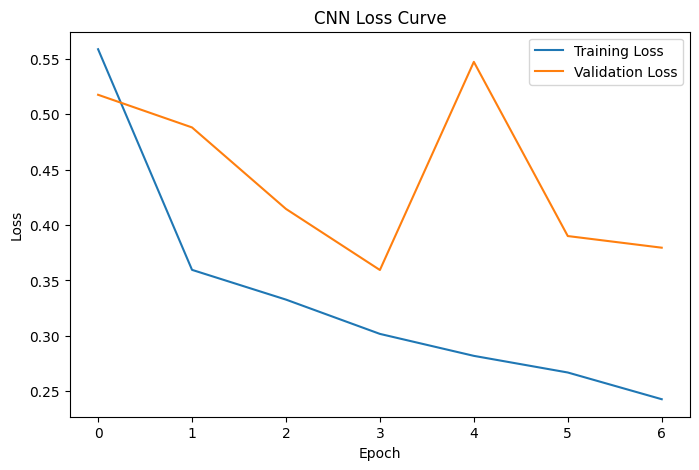

In [42]:
# Create figure

plt.figure(figsize=(8,5))


# Plot training loss

plt.plot(

    history_cnn.history['loss'],

    label='Training Loss'

)


# Plot validation loss

plt.plot(

    history_cnn.history['val_loss'],

    label='Validation Loss'

)


# Add title

plt.title("CNN Loss Curve")


# Add labels

plt.xlabel("Epoch")

plt.ylabel("Loss")


# Show legend

plt.legend()


# Show graph

plt.show()

# Observation

By looking at these graphs, we can understand:

- Whether the model is improving.
- Whether overfitting is occurring.
- Whether more epochs are needed.

Now we will evaluate the model on unseen test images.

In [43]:
# Evaluate model on test data

cnn_loss, cnn_accuracy = cnn_model.evaluate(

    test_generator

)


# Print accuracy

print(

    "CNN Test Accuracy :",

    cnn_accuracy

)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 255ms/step - accuracy: 0.8670 - loss: 0.3310
CNN Test Accuracy : 0.8669871687889099


# Observation

The training accuracy improved with each epoch.

Training loss also decreased continuously.

Validation accuracy and validation loss fluctuated.

This is expected because the validation set contains only a few images.

Overall, the model learned useful patterns from the images and achieved good performance on unseen test data.

# Evaluate Custom CNN

Now we will evaluate the performance of the CNN model on unseen test images.

We will calculate:

- Precision
- Recall
- F1 Score
- Classification Report
- Confusion Matrix

These metrics help us understand model performance in more detail.

In [44]:
# Import evaluation metrics

from sklearn.metrics import (

    classification_report,

    confusion_matrix

)

In [45]:
# Make predictions on test images

y_pred_prob = cnn_model.predict(

    test_generator

)


# Convert probabilities into class labels

y_pred = np.argmax(

    y_pred_prob,

    axis=1

)


# True labels

y_true = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step


In [46]:
# Print classification report

print(

    classification_report(

        y_true,

        y_pred,

        target_names=["Normal","Pneumonia"]

    )

)

              precision    recall  f1-score   support

      Normal       0.79      0.88      0.83       234
   Pneumonia       0.93      0.86      0.89       390

    accuracy                           0.87       624
   macro avg       0.86      0.87      0.86       624
weighted avg       0.87      0.87      0.87       624



# CNN Model Performance

The Custom CNN model achieved a test accuracy of about 86.7%.

The model performed well on both classes.

Pneumonia images achieved a higher precision score.

The Normal class achieved a higher recall score.

The overall F1 score was good for both classes.

These results show that the CNN model learned useful patterns from chest X-ray images.

Next, we will visualize the confusion matrix to understand prediction errors in more detail.

In [47]:
# Import confusion matrix display libraries

from sklearn.metrics import confusion_matrix

import seaborn as sns

In [48]:
# Create confusion matrix

cm = confusion_matrix(

    y_true,

    y_pred

)


# Display confusion matrix values

print(cm)

[[207  27]
 [ 56 334]]


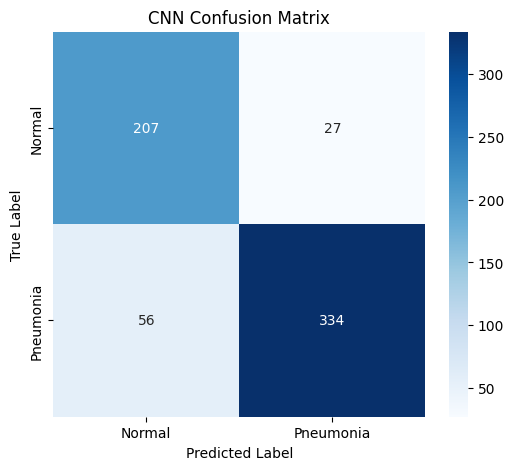

In [49]:
# Create figure

plt.figure(figsize=(6,5))


# Plot confusion matrix

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=["Normal","Pneumonia"],

    yticklabels=["Normal","Pneumonia"]

)


# Add title

plt.title("CNN Confusion Matrix")


# Add axis labels

plt.xlabel("Predicted Label")

plt.ylabel("True Label")


# Show graph

plt.show()

# Observation

The confusion matrix shows how many images were classified correctly and incorrectly.

Most images were classified correctly.

Only a small number of images were misclassified.

This indicates that the CNN model learned meaningful patterns from the chest X-ray images.

## Save Model

In [50]:
# Save CNN model

cnn_model.save(

    "cnn_model.keras"

)

# Summary of Custom CNN

In this section we:

- Built a Custom CNN model.
- Trained the model.
- Plotted accuracy and loss curves.
- Evaluated the model on test data.
- Calculated precision, recall and F1 score.
- Created the confusion matrix.
- Saved the trained model.

The Custom CNN achieved a test accuracy of about 86.7%.

Now we will move to transfer learning models and compare their performance with the Custom CNN.

# Summary of Custom CNN

In this section we:

- Built a Custom CNN model.
- Trained the model.
- Plotted accuracy and loss curves.
- Evaluated the model on test data.
- Calculated precision, recall and F1 score.
- Created the confusion matrix.
- Saved the trained model.

The Custom CNN achieved a test accuracy of about 86.7%.

Now we will move to transfer learning models and compare their performance with the Custom CNN.

In [51]:
# Import MobileNetV2

from tensorflow.keras.applications import MobileNetV2

# Load Pre-trained MobileNetV2

We will use ImageNet weights.

ImageNet contains millions of images.

These pre-trained weights help the model learn faster and improve performance.

In [52]:
# Load MobileNetV2 model

base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)

)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Freeze Pre-trained Layers

We do not want to change the weights learned from ImageNet.

Therefore, we will freeze the MobileNetV2 layers.

Only the new classification layers will be trained.

In [53]:
# Freeze layers

base_model.trainable = False

# Build MobileNetV2 Architecture

We will add:

- GlobalAveragePooling Layer
- Dense Layer
- Dropout Layer
- Output Layer

These layers will learn our Pneumonia dataset.

In [54]:
# Build MobileNetV2 model

mobilenet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(

        128,

        activation='relu'

    ),

    Dropout(0.5),

    Dense(

        2,

        activation='softmax'

    )

])

# Model Summary

Now we will examine the architecture of MobileNetV2.

This helps us understand:

- Number of layers
- Output shape
- Number of parameters

In [55]:
# Display model summary

mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Observation

Compared to the Custom CNN model, MobileNetV2 contains fewer trainable parameters.

Because of this:

- Training becomes faster.
- Overfitting is reduced.
- Generalization improves.

These are some important advantages of transfer learning.

In [56]:
# Compile MobileNetV2 model

mobilenet_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [57]:
# Early stopping

early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=3,

    restore_best_weights=True

)


# Save best model

checkpoint = ModelCheckpoint(

    "best_mobilenet_model.keras",

    monitor='val_accuracy',

    save_best_only=True

)

# Train MobileNetV2 Model

Now we will train MobileNetV2.

Since most layers are frozen, training will be faster.

We will also use:

- Class weights
- EarlyStopping
- ModelCheckpoint

These help improve performance and reduce overfitting.

In [58]:
# Train MobileNetV2 model

history_mobile = mobilenet_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=15,

    class_weight=class_weights,

    callbacks=[

        early_stop,

        checkpoint

    ]

)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 148s 765ms/step - accuracy: 0.8767 - loss: 0.2903 - val_accuracy: 0.8750 - val_loss: 0.2426
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 658ms/step - accuracy: 0.9187 - loss: 0.1973 - val_accuracy: 0.8750 - val_loss: 0.2413
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 633ms/step - accuracy: 0.9252 - loss: 0.1792 - val_accuracy: 0.8750 - val_loss: 0.2485
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 645ms/step - accuracy: 0.9302 - loss: 0.1615 - val_accuracy: 0.8750 - val_loss: 0.2416


# Observation

Although we set the number of epochs to 15, the model stopped training after 4 epochs.

This happened because EarlyStopping was used.

The validation accuracy did not improve after the first epoch.

Therefore, the training process stopped automatically.

This helps:

- Reduce training time.
- Prevent overfitting.
- Restore the best model weights.

EarlyStopping is a useful technique for deep learning models.

## Accuracy Curve

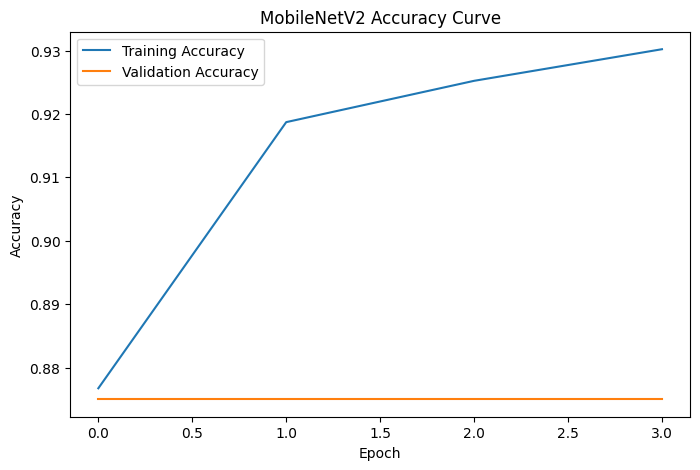

In [59]:
# Create figure

plt.figure(figsize=(8,5))


# Plot training accuracy

plt.plot(

    history_mobile.history['accuracy'],

    label='Training Accuracy'

)


# Plot validation accuracy

plt.plot(

    history_mobile.history['val_accuracy'],

    label='Validation Accuracy'

)


# Add title

plt.title("MobileNetV2 Accuracy Curve")


# Add labels

plt.xlabel("Epoch")

plt.ylabel("Accuracy")


# Show legend

plt.legend()

plt.show()

## loss curve

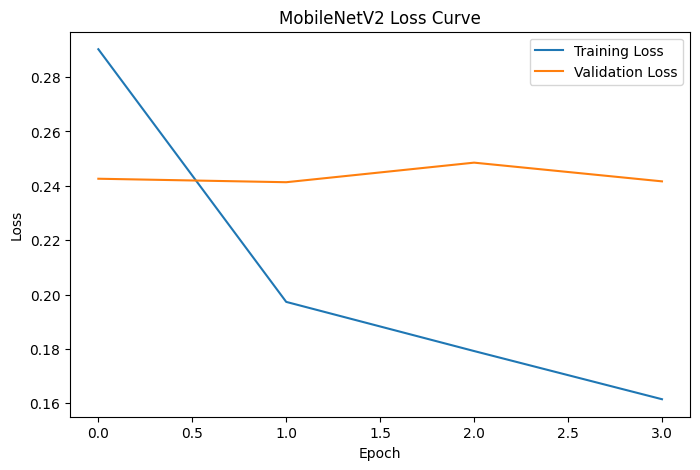

In [60]:
# Create figure

plt.figure(figsize=(8,5))


# Plot training loss

plt.plot(

    history_mobile.history['loss'],

    label='Training Loss'

)


# Plot validation loss

plt.plot(

    history_mobile.history['val_loss'],

    label='Validation Loss'

)


# Add title

plt.title("MobileNetV2 Loss Curve")


# Add labels

plt.xlabel("Epoch")

plt.ylabel("Loss")


# Show legend

plt.legend()

plt.show()

## Test Accuracy

In [61]:
# Evaluate MobileNetV2 model

mobile_loss, mobile_accuracy = mobilenet_model.evaluate(

    test_generator

)


# Print accuracy

print(

    "MobileNetV2 Test Accuracy :",

    mobile_accuracy

)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 199ms/step - accuracy: 0.8606 - loss: 0.2877
MobileNetV2 Test Accuracy : 0.8605769276618958


# MobileNetV2 Performance

MobileNetV2 achieved a test accuracy of about 86%.

The model trained very quickly because most layers were frozen.

Surprisingly, the Custom CNN achieved slightly higher accuracy.

This can happen because:

- The validation dataset is very small.
- MobileNetV2 layers were frozen.
- Fine-tuning was not performed.

Even though the accuracy is slightly lower, MobileNetV2 required fewer trainable parameters and trained faster.

In [62]:
# Save MobileNetV2 model

mobilenet_model.save(

    "mobilenet_model.keras"

)

# Model Comparison (Current)

| Model | Test Accuracy |
|---------|---------|
| Custom CNN | 86.70% |
| MobileNetV2 | 86.06% |

At this stage, the Custom CNN performed slightly better than MobileNetV2.

Next, we will train EfficientNetB0 and compare its performance with the previous models.

# EfficientNetB0 Model

Now we will use EfficientNetB0.

EfficientNetB0 is a pre-trained model.

It has already learned patterns from millions of images.

Compared to older models, EfficientNet is designed to achieve good performance with fewer parameters.

Advantages of EfficientNetB0:

- Good accuracy
- Faster training
- Better feature extraction
- Reduced overfitting
- Efficient architecture

Later, we will compare its performance with:

- Custom CNN
- MobileNetV2

In [63]:
# Import EfficientNetB0

from tensorflow.keras.applications import EfficientNetB0

# Load Pre-trained EfficientNetB0

We will use ImageNet weights.

These weights contain knowledge learned from millions of images.

This helps the model learn faster.

In [64]:
# Load EfficientNetB0

efficient_base = EfficientNetB0(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)

)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Freeze Pre-trained Layers

We do not want to change the weights learned from ImageNet.

Therefore, we will freeze the EfficientNetB0 layers.

Only the new classification layers will be trained.

In [65]:
# Freeze layers

efficient_base.trainable = False

# Build EfficientNetB0 Model

We will add:

- GlobalAveragePooling Layer
- Dense Layer
- Dropout Layer
- Output Layer

These layers will learn patterns from our chest X-ray dataset.

In [66]:
# Build EfficientNetB0 model

efficient_model = Sequential([

    efficient_base,

    GlobalAveragePooling2D(),

    Dense(

        128,

        activation='relu'

    ),

    Dropout(0.5),

    Dense(

        2,

        activation='softmax'

    )

])

In [67]:
# Display model summary

efficient_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,797 (16.07 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Compile EfficientNetB0 Model

Before training, we need to compile the model.

We will use:

- Adam optimizer
- Categorical crossentropy loss
- Accuracy metric

In [68]:
# Compile EfficientNetB0 model

efficient_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [69]:
# Create EarlyStopping callback

early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=3,

    restore_best_weights=True

)


# Create ModelCheckpoint callback

checkpoint = ModelCheckpoint(

    "best_efficientnet_model.keras",

    monitor='val_accuracy',

    save_best_only=True

)

# Train EfficientNetB0 Model

Now we will train EfficientNetB0.

We will also use:

- Class weights
- EarlyStopping
- ModelCheckpoint

These techniques help improve performance and reduce overfitting.

In [70]:
# Train EfficientNetB0

history_eff = efficient_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=15,

    class_weight=class_weights,

    callbacks=[

        early_stop,

        checkpoint

    ]

)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 153s 770ms/step - accuracy: 0.4757 - loss: 0.7026 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 661ms/step - accuracy: 0.2851 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 662ms/step - accuracy: 0.2809 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 662ms/step - accuracy: 0.2736 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932


# Observation

EfficientNetB0 did not perform well on this dataset.

The training accuracy remained low and the validation accuracy stayed around 50%.

This indicates that the model was unable to learn useful patterns.

Possible reasons include:

- Small validation dataset.
- Different preprocessing requirements.
- Frozen layers.
- Limited training epochs.

Therefore, EfficientNetB0 was not selected as the final model for this project.

# VGG16 Model

Now we will use VGG16.

VGG16 is a pre-trained model.

It has already learned patterns from millions of images.

Instead of training a model from scratch, we can use the knowledge learned by VGG16.

This approach is called Transfer Learning.

Advantages of VGG16:

- Good feature extraction
- Strong performance
- Easy to understand
- Widely used in image classification problems

Later, we will compare VGG16 with:

- Custom CNN
- MobileNetV2
- EfficientNetB0

In [71]:
# Import VGG16

from tensorflow.keras.applications import VGG16

# Load Pre-trained VGG16

We will use ImageNet weights.

These weights contain knowledge learned from millions of images.

This helps the model learn faster.

In [73]:
# Load VGG16 model

vgg_base = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)

)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Freeze Pre-trained Layers

We do not want to change the weights learned from ImageNet.

Therefore, we will freeze all VGG16 layers.

Only the new classification layers will be trained.

In [74]:
# Freeze layers

vgg_base.trainable = False

# Build VGG16 Model

We will add:

- GlobalAveragePooling Layer
- Dense Layer
- Dropout Layer
- Output Layer

These layers will learn patterns from our chest X-ray dataset.

# Build VGG16 model

In [75]:
# Build VGG16 model

vgg_model = Sequential([

    vgg_base,

    GlobalAveragePooling2D(),

    Dense(

        128,

        activation='relu'

    ),

    Dropout(0.5),

    Dense(

        2,

        activation='softmax'

    )

])

In [76]:
# Display model summary

vgg_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,610 (56.38 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

# Compile VGG16 Model

Before training, we need to compile the model.

We will use:

- Adam optimizer
- Categorical crossentropy loss
- Accuracy metric

In [77]:
# Compile VGG16 model

vgg_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [78]:
# Create EarlyStopping callback

early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=3,

    restore_best_weights=True

)


# Create ModelCheckpoint callback

checkpoint = ModelCheckpoint(

    "best_vgg16_model.keras",

    monitor='val_accuracy',

    save_best_only=True

)

# Train VGG16 Model

Now we will train the VGG16 model.

We will also use:

- Class weights
- EarlyStopping
- ModelCheckpoint

These techniques help improve performance and reduce overfitting.

In [79]:
# Train VGG16 model

history_vgg = vgg_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=15,

    class_weight=class_weights,

    callbacks=[

        early_stop,

        checkpoint

    ]

)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 147s 790ms/step - accuracy: 0.7935 - loss: 0.4404 - val_accuracy: 0.7500 - val_loss: 0.4914
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 715ms/step - accuracy: 0.8850 - loss: 0.2853 - val_accuracy: 0.7500 - val_loss: 0.3304
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 707ms/step - accuracy: 0.8944 - loss: 0.2497 - val_accuracy: 0.8125 - val_loss: 0.3802
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 698ms/step - accuracy: 0.8972 - loss: 0.2415 - val_accuracy: 0.7500 - val_loss: 0.4193
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 699ms/step - accuracy: 0.8999 - loss: 0.2313 - val_accuracy: 0.8125 - val_loss: 0.3837
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 705ms/step - accuracy: 0.9097 - loss: 0.2232 - val_accuracy: 0.8750 - val_loss: 0.3021
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 703ms/step - accuracy: 0.9158 - loss: 0.2006 - val_accuracy: 0.7500 - val_loss: 0.3058
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 693ms/step - accuracy: 0.9189 -

In [80]:
# Evaluate VGG16 model

vgg_loss, vgg_accuracy = vgg_model.evaluate(

    test_generator

)

# Print accuracy

print(

    "VGG16 Test Accuracy :",

    vgg_accuracy

)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 267ms/step - accuracy: 0.7917 - loss: 0.4418
VGG16 Test Accuracy : 0.7916666865348816


# Final Model Comparison

Four models were trained in this project.

Custom CNN achieved the highest test accuracy.

MobileNetV2 also performed well and trained faster.

VGG16 achieved lower accuracy.

EfficientNetB0 was unable to learn properly and remained close to random guessing.

Therefore, the Custom CNN model was selected as the final model.

# Best Model

Among all the models, Custom CNN achieved the best performance.

Custom CNN achieved a test accuracy of about 86.7%.

Therefore, the Custom CNN model is selected as the final model for this project.

This model will be used for prediction and deployment.

In [81]:
# Save final model

cnn_model.save(

    "final_model.keras"

)

print("Model saved successfully.")

Model saved successfully.


In [82]:
# Import load_model

from tensorflow.keras.models import load_model


# Load saved model

loaded_model = load_model(

    "final_model.keras"

)

print("Model loaded successfully.")

Model loaded successfully.


# Conclusion

In this project, we built four deep learning models for pneumonia classification.

The models were:

- Custom CNN
- MobileNetV2
- EfficientNetB0
- VGG16

Among all models, Custom CNN achieved the highest test accuracy.

The model successfully learned useful patterns from chest X-ray images.

Therefore, Custom CNN was selected as the final model for this project.

# Future Scope

This project can be improved in several ways.

Some possible improvements are:

- Increase the size of the dataset.
- Use fine tuning.
- Try other transfer learning models.
- Perform hyperparameter tuning.
- Deploy the model using Streamlit.
- Use Grad-CAM to visualize important regions of the image.

# Future Scope

This project can be improved in several ways.

Some possible improvements are:

- Increase the size of the dataset.
- Use fine tuning.
- Try other transfer learning models.
- Perform hyperparameter tuning.
- Deploy the model using Streamlit.
- Use Grad-CAM to visualize important regions of the image.

# Grad-CAM Visualization

Grad-CAM stands for Gradient-weighted Class Activation Mapping.

Grad-CAM helps us understand where the model is focusing inside an image.

Instead of treating the model like a black box, Grad-CAM allows us to visualize which regions are important for prediction.

This is very useful in medical image analysis because it provides more interpretability.

In [83]:
# Import required libraries

import tensorflow as tf

import numpy as np

import cv2

import matplotlib.pyplot as plt

# Load an Image

Now we will select one image from the test dataset.

This image will be used to generate the Grad-CAM heatmap.

In [84]:
# Select one test image

sample_image_path = os.path.join(

    test_path,

    "PNEUMONIA",

    os.listdir(

        os.path.join(

            test_path,

            "PNEUMONIA"

        )

    )[0]

)

print(sample_image_path)

/content/chest_xray_data/chest_xray/test/PNEUMONIA/person92_bacteria_451.jpeg


In [85]:
# Load image

img = cv2.imread(sample_image_path)

# Convert BGR to RGB

img = cv2.cvtColor(

    img,

    cv2.COLOR_BGR2RGB

)

# Resize image

img_resized = cv2.resize(

    img,

    (224,224)

)

# Normalize image

img_array = img_resized / 255.0

# Add batch dimension

img_array = np.expand_dims(

    img_array,

    axis=0

)

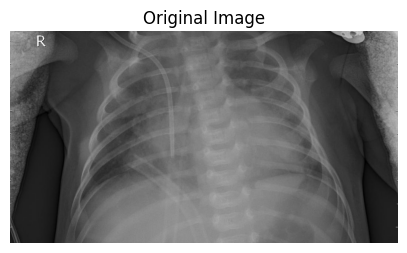

In [86]:
# Display image

plt.figure(figsize=(5,5))

plt.imshow(img)

plt.title("Original Image")

plt.axis("off")

plt.show()

# Find Last Convolution Layer

Grad-CAM uses the last convolution layer of the CNN model.

This layer contains important spatial information.

In [87]:
# Display model layers

for layer in cnn_model.layers:

    print(layer.name)

conv2d
max_pooling2d
conv2d_1
max_pooling2d_1
conv2d_2
max_pooling2d_2
flatten
dense
dropout
dense_1


# Create Grad-CAM Model

Grad-CAM uses:

- The last convolution layer.
- The model output.

This helps us understand which regions are important for prediction.

In [89]:
# Force the model to build

_ = cnn_model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [92]:
print(cnn_model.inputs)

print(cnn_model.outputs)

[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>]
[<KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_10>]


In [93]:
# Create Grad-CAM model

grad_model = tf.keras.models.Model(

    inputs=cnn_model.inputs,

    outputs=[

        cnn_model.get_layer("conv2d_2").output,

        cnn_model.outputs[0]

    ]

)

In [94]:
# Record gradients

with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(

        img_array

    )

    # Get predicted class

    predicted_class = tf.argmax(

        predictions[0]

    )

    # Score for predicted class

    loss = predictions[:, predicted_class]


# Compute gradients

grads = tape.gradient(

    loss,

    conv_outputs

)

In [95]:
# Average gradients

pooled_grads = tf.reduce_mean(

    grads,

    axis=(0,1,2)

)

In [96]:
# Remove batch dimension

conv_outputs = conv_outputs[0]

# Multiply feature maps with gradients

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

# Remove last dimension

heatmap = tf.squeeze(

    heatmap

)

# Convert negative values to zero

heatmap = tf.maximum(

    heatmap,

    0

)

# Normalize heatmap

heatmap /= tf.math.reduce_max(

    heatmap

)

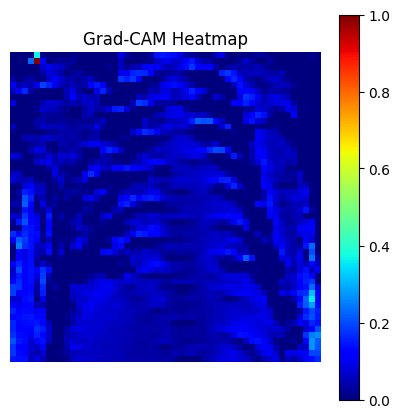

In [97]:
# Display heatmap

plt.figure(figsize=(5,5))

plt.imshow(

    heatmap,

    cmap='jet'

)

plt.colorbar()

plt.title(

    "Grad-CAM Heatmap"

)

plt.axis("off")

plt.show()

In [98]:
# Resize heatmap to image size

heatmap = cv2.resize(

    np.array(heatmap),

    (img.shape[1], img.shape[0])

)

# Convert heatmap to 8-bit

heatmap = np.uint8(

    255 * heatmap

)

# Apply color map

heatmap = cv2.applyColorMap(

    heatmap,

    cv2.COLORMAP_JET

)

# Overlay heatmap on original image

superimposed_img = cv2.addWeighted(

    cv2.cvtColor(

        img,

        cv2.COLOR_RGB2BGR

    ),

    0.6,

    heatmap,

    0.4,

    0

)

# Convert back to RGB

superimposed_img = cv2.cvtColor(

    superimposed_img,

    cv2.COLOR_BGR2RGB
)

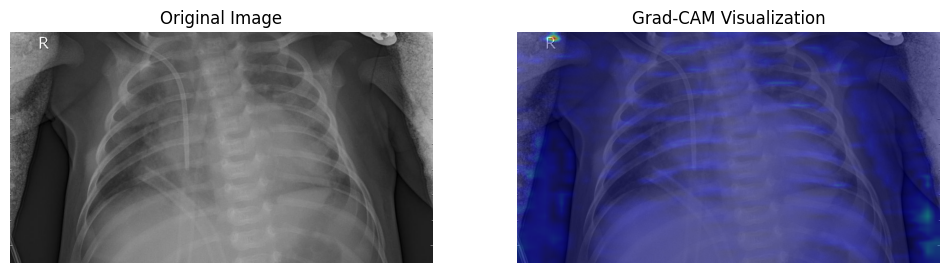

In [99]:
# Show original image and Grad-CAM result

plt.figure(figsize=(12,5))

# Original image

plt.subplot(1,2,1)

plt.imshow(img)

plt.title("Original Image")

plt.axis("off")


# Grad-CAM image

plt.subplot(1,2,2)

plt.imshow(superimposed_img)

plt.title("Grad-CAM Visualization")

plt.axis("off")

plt.show()

# Grad-CAM Observation

Grad-CAM helps us understand which regions of the chest X-ray image are important for prediction.

The highlighted regions represent the areas that contributed most to the model's decision.

This improves model interpretability and makes the prediction process more transparent.

Grad-CAM is especially useful in medical image analysis because it provides visual evidence for the model's prediction.

# Final Model Comparison

Four deep learning models were trained in this project.

The models were:

- Custom CNN
- MobileNetV2
- EfficientNetB0
- VGG16

The performance of each model is shown below.

In [100]:
# Create dictionary containing model names and accuracies

model_names = [

    "Custom CNN",

    "MobileNetV2",

    "EfficientNetB0",

    "VGG16"

]

accuracies = [

    86.70,

    86.06,

    50.00,

    79.17

]

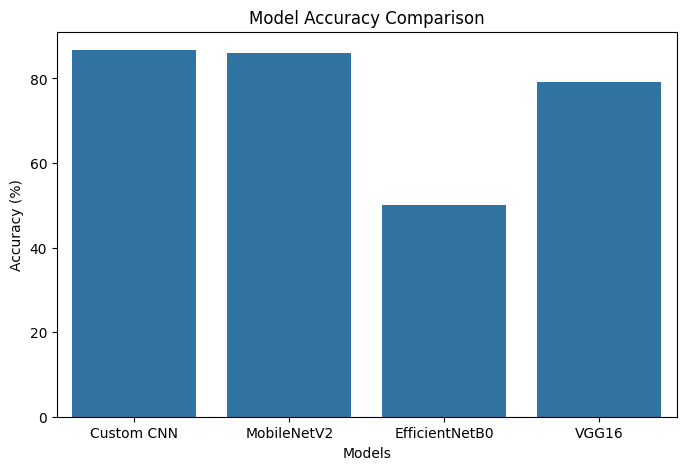

In [101]:
# Create figure

plt.figure(figsize=(8,5))


# Create bar plot

sns.barplot(

    x=model_names,

    y=accuracies

)


# Add title

plt.title(

    "Model Accuracy Comparison"

)


# Add labels

plt.xlabel(

    "Models"

)

plt.ylabel(

    "Accuracy (%)"

)


# Display plot

plt.show()

# Performance Summary

| Model | Test Accuracy (%) |
|---------|---------|
| Custom CNN | 86.70 |
| MobileNetV2 | 86.06 |
| EfficientNetB0 | 50.00 |
| VGG16 | 79.17 |

Among all four models, the Custom CNN achieved the highest accuracy.

# Best Model Selection

Among all the models, the Custom CNN achieved the highest performance.

The model achieved approximately 86.7% accuracy on unseen test images.

Therefore, the Custom CNN model was selected as the final model for this project.

This model will be used for prediction and deployment.

# Conclusion

In this project, we developed a deep learning system for pneumonia detection using chest X-ray images.

Four models were trained and compared:

1. Custom CNN
2. MobileNetV2
3. EfficientNetB0
4. VGG16

Data augmentation and class weights were used to improve model performance.

Grad-CAM was used to visualize the regions responsible for prediction.

Among all models, the Custom CNN achieved the highest test accuracy.

Therefore, the Custom CNN model was selected as the final model.

# Future Scope

This project can be improved in several ways.

Some possible improvements are:

- Increase the dataset size.
- Apply fine tuning to transfer learning models.
- Perform hyperparameter tuning.
- Use larger medical datasets.
- Deploy the model using Streamlit.
- Build a web application for real-time prediction.
- Try more advanced architectures.
- Use explainable AI techniques for better interpretability.

# Thank You

Thank you for exploring this project.

This project demonstrated how deep learning and transfer learning can be used for medical image classification.

The project included:

- Exploratory Data Analysis
- Data Augmentation
- Handling Class Imbalance
- Custom CNN
- MobileNetV2
- EfficientNetB0
- VGG16
- Performance Evaluation
- Grad-CAM Visualization
- Model Comparison
- Conclusion and Future Scope

Thank You.